<a href="https://colab.research.google.com/github/Sam-Arkle/CS5455/blob/main/ex1_4_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

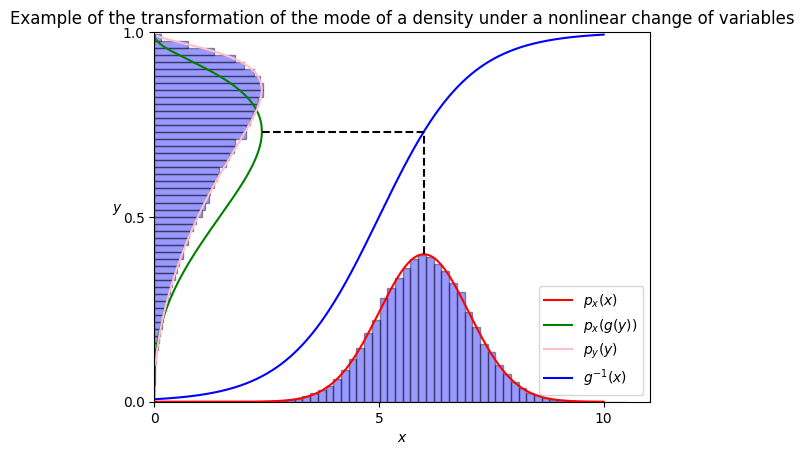

In [30]:
from scipy.stats import norm
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

mean = 6
standard_deviation = 1

x_data = np.linspace(0,10,50_000) # plot 50,000 points along our x axis
y_data = norm.pdf(x_data, mean, standard_deviation)

norm_data = np.random.normal(mean, standard_deviation, 50_000) # data with a normal distribution

# Generating g(y)
y_vals = np.linspace(0.1, 0.99, 50_000)  # Use values from (0, 1) to avoid log(0) issues
g_y = [np.log(y) - np.log(1-y) + 5 for y in y_data]
g_y = [np.log(y) - np.log(1-y) + 5 for y in y_vals]


#Generating the data for the sigmoid curve
g_inverse = [1 / (1 + np.e**(-x + 5)) for x in x_data]
def g_inverse_func(y):
  return 1 / (1 + np.e**(-y + 5))

#Generating the histogram for the y-axis
y_histo = [1 / (1 + np.e**(-x + 5)) for x in norm_data]

# Generating the data for the green curve
y_green = g_inverse_func(x_data)
x_green = y_data * mean

#Generating the data for p_y(y)
g_y_diff = 1 / (y_vals - y_vals**2)
p_y = norm.pdf(g_y, mean, standard_deviation) * np.abs(g_y_diff)
transformed_x = norm.pdf, p_y, mean, standard_deviation


# Plotting the graph
plt.plot(x_data, y_data, color='red', label = '$p_x(x)$')
plt.plot(x_green, y_green, color='green', label = '$p_x(g(y))$')
plt.plot(p_y, y_vals, color='pink', label='$p_y(y)$')
plt.plot(x_data, g_inverse, color = 'blue', label = '$g^{-1}(x)$')
plt.hist(norm_data, bins=50, density=True, alpha=0.4, color='blue',  edgecolor='black')
plt.hist(y_histo, bins=50, density=True, alpha=0.4, color='blue', edgecolor='black',orientation='horizontal')

# Plotting the peak lines
red_peak, _ = find_peaks(y_data)
plt.plot([x_data[red_peak], x_data[red_peak]], [y_data[red_peak], g_inverse_func(x_data[red_peak])], linestyle='dashed', color='black')

green_peak, _ = find_peaks(x_green)

plt.plot([x_green[green_peak], x_data[red_peak]], [g_inverse_func(x_data[green_peak]), g_inverse_func(x_data[green_peak])], linestyle='dashed', color='black')


# Labelling
plt.xlabel("$x$")
plt.ylabel("$y$", rotation=0)
plt.title("Example of the transformation of the mode of a density under a nonlinear change of variables")
plt.xlim(left=0)
plt.ylim(bottom=0, top=1)
plt.yticks([0,0.5,1])
plt.xticks([0,5,10])

plt.legend()
plt.show()
